# EITN 2026 – MFM Group: Tutorial 2

In this tutorial, we will explore the intermediate step between a **Spiking Neural Network (SNN)** model and its use for the derivation and validation of a **Mean Field Model (MFM)**.

In particular, we will focus on a **mouse cerebellar cortical model** and generate numerical templates for deriving **population-specific MFM transfer functions**. We will also run **SNN simulations** that will subsequently be used to validate the resulting MFM.

# 0. Environment Setup

In [17]:
!pip install -q condacolab
import condacolab
condacolab.install()


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

✨🍰✨ Everything looks OK!


In [18]:
!mamba install -y -c conda-forge nest-simulator cmake compilers libboost-headers "sysroot_linux-64<2.34"

conda-forge/linux-64                                        Using cache
conda-forge/noarch                                          Using cache

Pinned packages:

  - python=3.13

Pinned packages:

  - python_abi[version="=3.13",build="*cp313*"]

Pinned packages:

  - cuda-version*.*

Pinned packages:

  - python=3.13


Transaction

  Prefix: /usr/local

  All requested packages already installed


Transaction starting
[+] 0.0s

Transaction finished



In [19]:
from google.colab import drive, output
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [42]:
import os
os.chdir("/content/drive/MyDrive/EITN_school_2026_MFM-main/Day2")

In [21]:
!pip install -r ../Colab/requirements.txt

  Using cached arborize-7.6.0-py3-none-any.whl
  Using cached nrn_patch-7.6.0-py3-none-any.whl
  Using cached nmodl_glia-7.6.0-py3-none-any.whl
  Using cached bsb_core-7.6.0-py3-none-any.whl
  Using cached bsb_hdf5-7.6.0-py3-none-any.whl
  Using cached bsb_json-7.6.0-py3-none-any.whl
  Using cached bsb_yaml-7.6.0-py3-none-any.whl
  Using cached bsb_otel-7.6.0-py3-none-any.whl
  Using cached bsb_nest-7.6.0-py3-none-any.whl
  Using cached bsb_native-7.4.0-cp310-abi3-linux_x86_64.whl
  Using cached bsb-7.6.0-py3-none-any.whl
  Cloning https://github.com/dbbs-lab/cerebellar-models.git (to revision feature/auto_mfm) to /tmp/pip-install-zsuh19t7/cerebellar-models_f6d5ba95a5d64fd6ab3b17842caac0c3
  Running command git clone --filter=blob:none --quiet https://github.com/dbbs-lab/cerebellar-models.git /tmp/pip-install-zsuh19t7/cerebellar-models_f6d5ba95a5d64fd6ab3b17842caac0c3
  Running command git checkout -b feature/auto_mfm --track origin/feature/auto_mfm
  Switched to a new branch 'feature/

In [22]:
!cerebellar-models build-nestml

Building NESTML models...

             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0
 Built  : Jun 12 2026 10:07:47

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0
 Built  : Jun 12 2026 10:07:47

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

The computation had not completed because of the undecidable set membership is found in every candidates.
CMake Warning:
  Ignoring empty string ("") provided on the command line.


-- The CXX compiler identification is GNU 15.2.0
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
--

In [23]:
%matplotlib inline
%env MPLBACKEND=Agg

env: MPLBACKEND=Agg


In [48]:
from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np

# 1. SNN reconstruction and simulations

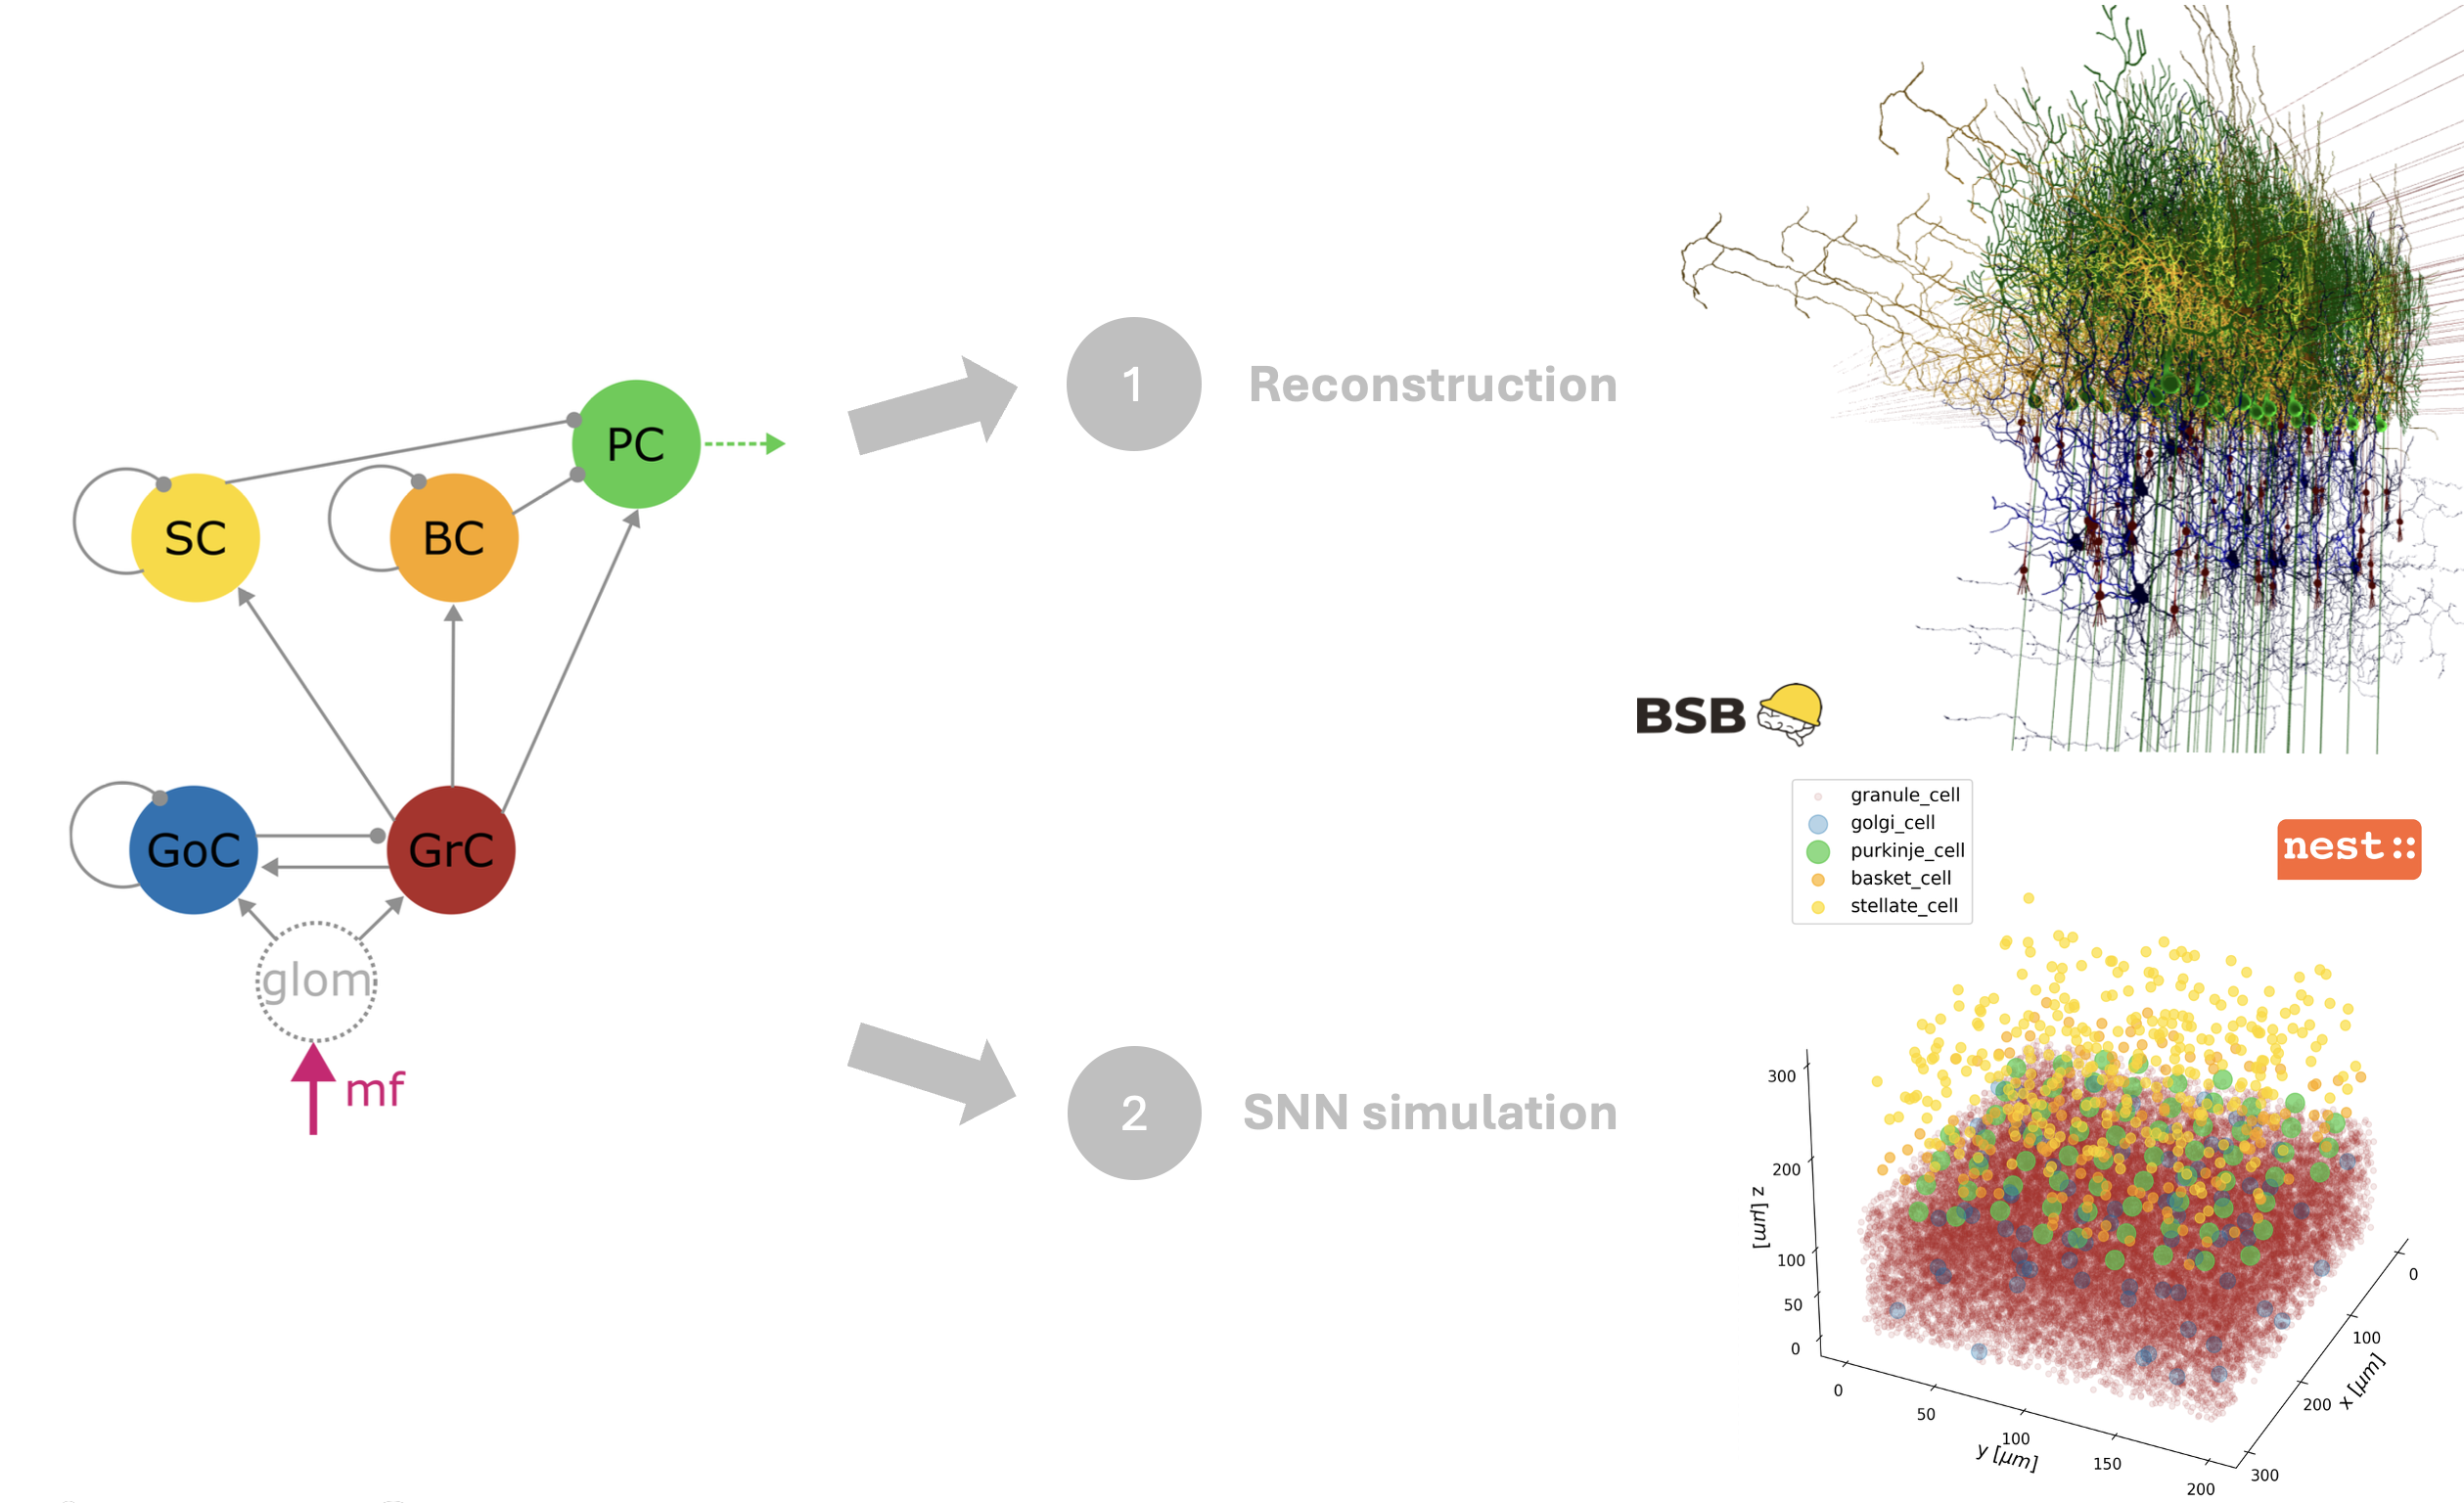

In [28]:
display(Image('figs/fig1.png'))

We focus on a mouse cerebellar cortical microcircuit comprising the main neuronal populations of the granular, Purkinje cell, and molecular layers: granule cells (GrC), Golgi cells (GoC), Purkinje cells (PC), and molecular layer interneurons (stellate, SC, and basket, BC cells), with mossy fiber (mf) inputs.

The model is built, configured, and simulated using the Python-based Brain Scaffold Builder ([BSB](https://bsb.readthedocs.io/en/latest/) framework.

The model represents a **300 × 200 × 295 µm** volume. Cell placement is defined according to **cell-density data from the literature**, while connectivity is reconstructed mainly through **voxel intersections between neuronal morphologies**, following the configuration proposed by De Schepper et al. (2022) (doi: 10.1038/s42003-022-04213-y).

Since the reconstruction step is computationally demanding, we will use the pre-generated `mouse_cerebellum.hdf5` file containing the reconstructed model. The reconstruction procedure can be performed by following the instructions in the [cerebellar-models documentation](https://cerebellar-models.readthedocs.io/en/latest/getting-started/getting-started.html).

In [26]:
# Download pre-compiled BSB reconstruction of cerebellar network

import gdown
from pathlib import Path
import os

FILE_ID = "12cRxjT5MTBNpklGmGwDPpoZS75-oT47G"
DEST_DIR = Path("/content/drive/MyDrive/EITN_school_2026_MFM-main/Day2/utils")
DEST_DIR.mkdir(parents=True, exist_ok=True)

gdown.download(id=FILE_ID, output=str(DEST_DIR) + "/", quiet=False)
os.chdir("/content/drive/MyDrive/EITN_school_2026_MFM-main/Day2")

Downloading...
From (original): https://drive.google.com/uc?id=12cRxjT5MTBNpklGmGwDPpoZS75-oT47G
From (redirected): https://drive.google.com/uc?id=12cRxjT5MTBNpklGmGwDPpoZS75-oT47G&confirm=t&uuid=86a27c79-3acc-4b4e-9d69-6be33d1abe05
To: /content/drive/MyDrive/EITN_school_2026_MFM-main/Day2/utils/mouse_cerebellum.hdf5
100%|██████████| 184M/184M [00:01<00:00, 100MB/s]


In [27]:
# Reconfigure the circuit and simulation settings for the tutorial
!bsb reconfigure ./utils/mouse_cerebellum.hdf5 ./utils/circuit_Z+.yaml


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0
 Built  : Jun 12 2026 10:07:47

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

/usr/local/lib/python3.13/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
Models is deprecated and will be removed in a future version of NEST.
Please use nest.node_models or nest.synapse_models instead!


/usr/local/lib/python3.13/site-packages/bsb/config/_make.py:252: KernelWarning:Could not validate cell model 'parrot_neuron': NEST kernel subprocess exited with code 1 before accepting a connection.
/usr/local/lib/python3.13/site-packages/bsb/config/_make.py:252: KernelWarning:Could not validate cell model 'eglif_cond_alpha_multisyn': NEST kernel subprocess exited with code 1 before accepting a connection.
/usr/local/lib/python3.13/site-packages/bsb/config/_make.py:252: KernelWarning:Could not determine if delay is required for synapse 'static_synapse': NEST kernel subprocess exited with code 1 before accepting a connection.
/usr/local/lib/python3.13/site-packages/bsb/config/_make.py:252: KernelWarning:Could not validate synapse model 'static_synapse': NEST kernel subprocess exited with code 1 before accepting a connection.


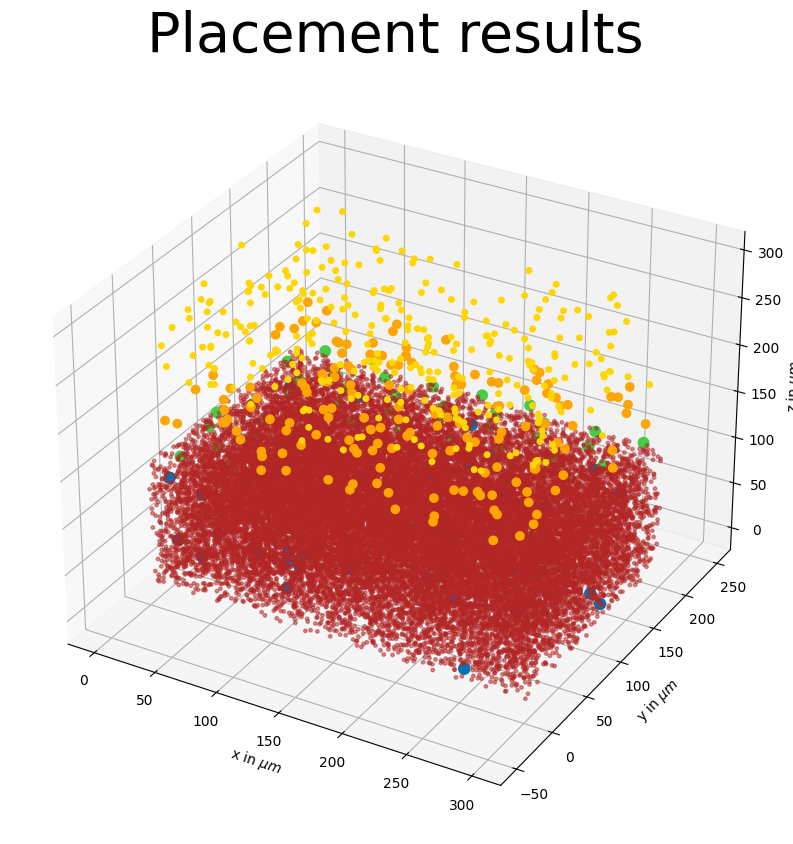

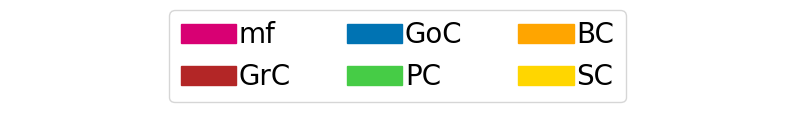

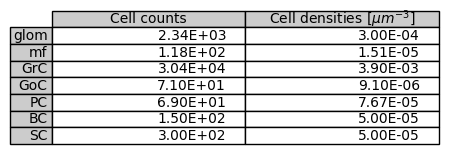

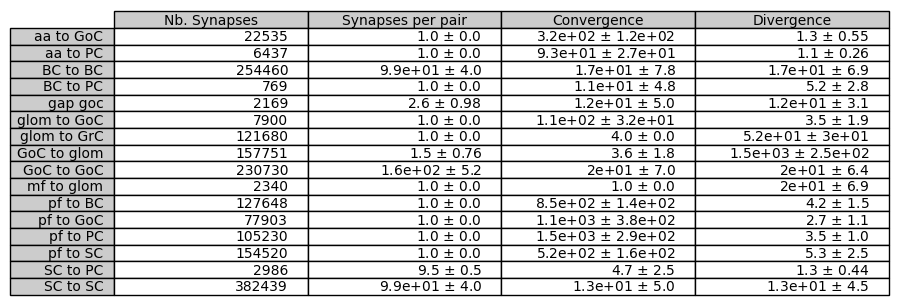

In [36]:
# Retrieve basic structural information from the BSB-reconstructed cerebellar cortex

from bsb import from_storage
from cerebellar_models.analysis.structure_analysis import StructureReport
from cerebellar_models.analysis.report import LIST_CT_INFO

scaffold = from_storage('./utils/mouse_cerebellum.hdf5')
report = StructureReport(scaffold, LIST_CT_INFO)

placement_3d = report.plots["placement_3d"]
placement_3d.plot()

legend = report.plots["legend"]
legend.plot()
legend.set_axis_off()

density_table = report.plots["density_table"]
density_table.update()
density_table.plot()
density_table.get_ax().set_axis_off()

connectivity_table = report.plots["connectivity_table"]
connectivity_table.update()
connectivity_table.plot()
connectivity_table.get_ax().set_axis_off()


Take particular note of:

* **Convergence:** average number of distinct presynaptic neurons providing input to each postsynaptic neuron.
* **Total number of synapses:** total number of synaptic connections in the reconstructed circuit.

These quantities will be used later for the derivation of the **MFM numerical templates**.


After reconstructing the microcircuit, we can **simulate** it using the BSB-NEST simulator interface and examine the resulting SNN activity. We will use the **EGLIF model**, with specific parameter sets for each neuronal population.
The parameter sets defined for each cell type can be found in ./utils/circuit_Z+.yaml.


In [44]:
# It will take about 30 min

!bsb simulate ./utils/mouse_cerebellum.hdf5 nest_simulation -o ./results_SNN --exists


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0
 Built  : Jun 12 2026 10:07:47

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

/usr/local/lib/python3.13/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
Models is deprecated and will be removed in a future version of NEST.
Please use nest.node_models or nest.synapse_models instead!
[INFO] [2026-09-22 21:20:29] Temporal resolution changed from 0.1 to 0.1 ms.
[INFO] [2026-09-22 21:20:29] loaded module cerebmodule
/usr/local/lib/python3.13/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
Provided for backward compatibility only. Set `nest.verbosity = nest.VerbosityLevel.XYZ` instead.


In [89]:
# If the simulation takes too long, you can retrieve the pre-run simulation results by executing this cell
import os
from pathlib import Path
import gdown

FOLDER_ID = "1VUiIz66YmDnd2fK-6LPw95IySoFV0TZb"
WORK_DIR = Path("/content/drive/MyDrive/EITN_school_2026_MFM-main/Day2")
RESULTS_DIR = WORK_DIR / "results_SNN"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

gdown.download_folder(id=FOLDER_ID, output=str(RESULTS_DIR), quiet=False)
os.chdir(WORK_DIR)

Retrieving folder contents


Processing file 1sGD4Qt_NagqWhrv5bZ_tu1DOtsNBkzDg 88c2df1a-32ea-4bdb-929f-ee4685822083.nio


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1sGD4Qt_NagqWhrv5bZ_tu1DOtsNBkzDg
To: /content/drive/MyDrive/EITN_school_2026_MFM-main/Day2/results_SNN/88c2df1a-32ea-4bdb-929f-ee4685822083.nio
100%|██████████| 12.2M/12.2M [00:00<00:00, 60.2MB/s]
Download completed


In [90]:
from matplotlib import gridspec as gs
from cerebellar_models.analysis.spike_plots import BasicSimulationReport

# Retrive results
report = BasicSimulationReport(
    scaffold="./utils/mouse_cerebellum.hdf5",
    simulation_name="nest_simulation",
    folder_nio="results_SNN",
)


/usr/local/lib/python3.13/site-packages/bsb/config/_make.py:252: KernelWarning:Could not validate cell model 'parrot_neuron': NEST kernel subprocess exited with code 1 before accepting a connection.
/usr/local/lib/python3.13/site-packages/bsb/config/_make.py:252: KernelWarning:Could not validate cell model 'eglif_cond_alpha_multisyn': NEST kernel subprocess exited with code 1 before accepting a connection.
/usr/local/lib/python3.13/site-packages/bsb/config/_make.py:252: KernelWarning:Could not determine if delay is required for synapse 'static_synapse': NEST kernel subprocess exited with code 1 before accepting a connection.
/usr/local/lib/python3.13/site-packages/bsb/config/_make.py:252: KernelWarning:Could not validate synapse model 'static_synapse': NEST kernel subprocess exited with code 1 before accepting a connection.


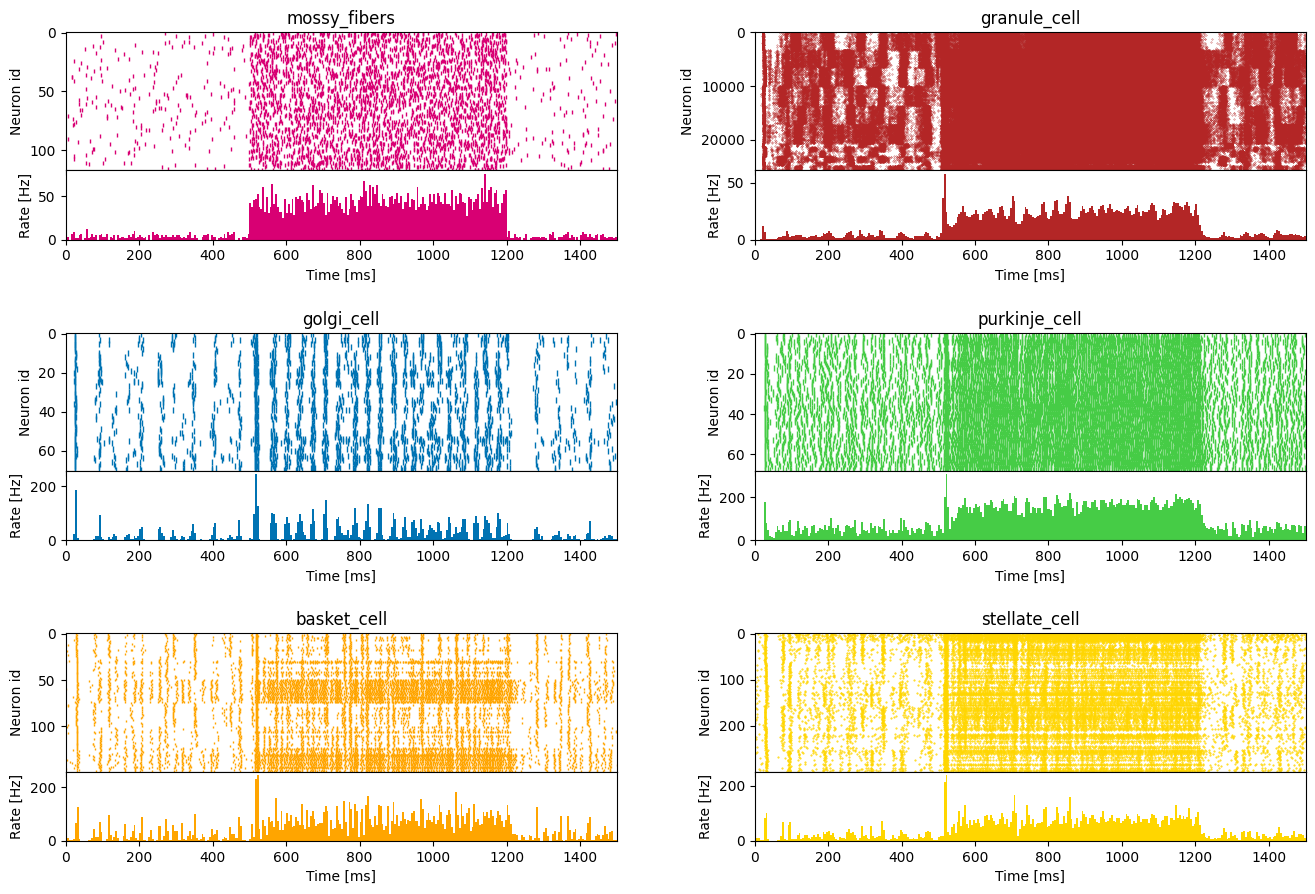

In [91]:
sr = report.spiking_results
t0, t1 = report.time_from, report.time_to
colors = report.plots["raster_psth"].labelled_dict_colors
n_neurons = dict(zip(sr.populations, sr.nb_neurons))

# Separate spike trains by population: {pop: {gid: spike times [ms]}}
spike_trains = {}
for pop, st in zip(sr.populations, sr.filt_spikes):
    times = st.magnitude
    senders = st.array_annotations["senders"]
    order = np.argsort(senders, kind="stable")
    gids, start = np.unique(senders[order], return_index=True)
    spike_trains[pop] = dict(zip(gids.astype(int), np.split(times[order], start[1:])))

# PSTH with 5-ms bins (population firing rate in Hz)
bin_ms = 5.0
bins = np.arange(t0, t1 + bin_ms, bin_ms)
psth = {}
for pop, trains in spike_trains.items():
    all_t = np.concatenate(list(trains.values())) if trains else np.array([])
    counts, _ = np.histogram(all_t, bins)
    psth[pop] = counts / (n_neurons[pop] * bin_ms / 1000.0) if n_neurons[pop] else counts * 0.0

# Raster + PSTH for each SNN population
pops = list(spike_trains)
n_rows = int(np.ceil(len(pops) / 2))
fig = plt.figure(figsize=(16, 3.5 * n_rows))
outer = gs.GridSpec(n_rows, 2, figure=fig, hspace=0.45, wspace=0.25)

for i, pop in enumerate(pops):
    inner = gs.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[i],
                                       height_ratios=[2, 1], hspace=0)
    ax_r = fig.add_subplot(inner[0])
    ax_p = fig.add_subplot(inner[1], sharex=ax_r)
    c = colors.get(pop, [0.6, 0.6, 0.6])[:3]
    trains = spike_trains[pop]

    if trains:
        xs = np.concatenate(list(trains.values()))
        ys = np.concatenate([np.full(len(t), k) for k, t in enumerate(trains.values())])
        n = len(trains)
        ax_r.plot(xs, ys, ls="none",
                  marker="|" if n < 200 else ".",
                  ms=np.clip(300 / n, 0.5, 4),
                  color=c, rasterized=True)
        ax_r.set_ylim(n - 0.5, -0.5)
    ax_r.set_ylabel("Neuron id")
    ax_r.set_title(pop)
    ax_r.tick_params(labelbottom=False)

    ax_p.stairs(psth[pop], bins, fill=True, color=c)
    ax_p.set_xlim(t0, t1)
    ax_p.set_xlabel("Time [ms]")
    ax_p.set_ylabel("Rate [Hz]")

plt.show()

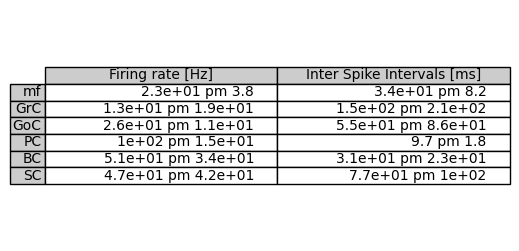

In [51]:
from cerebellar_models.analysis.spike_plots import SimResultsTable

table_plot = SimResultsTable(
    fig_size=(6, 3),
    spiking_results=report.spiking_results,
    dict_colors=report.plots["raster_psth"].labelled_dict_colors,
    dict_abv=report.abbreviations,
)
table_plot.plot()
table_plot.set_axis_off()

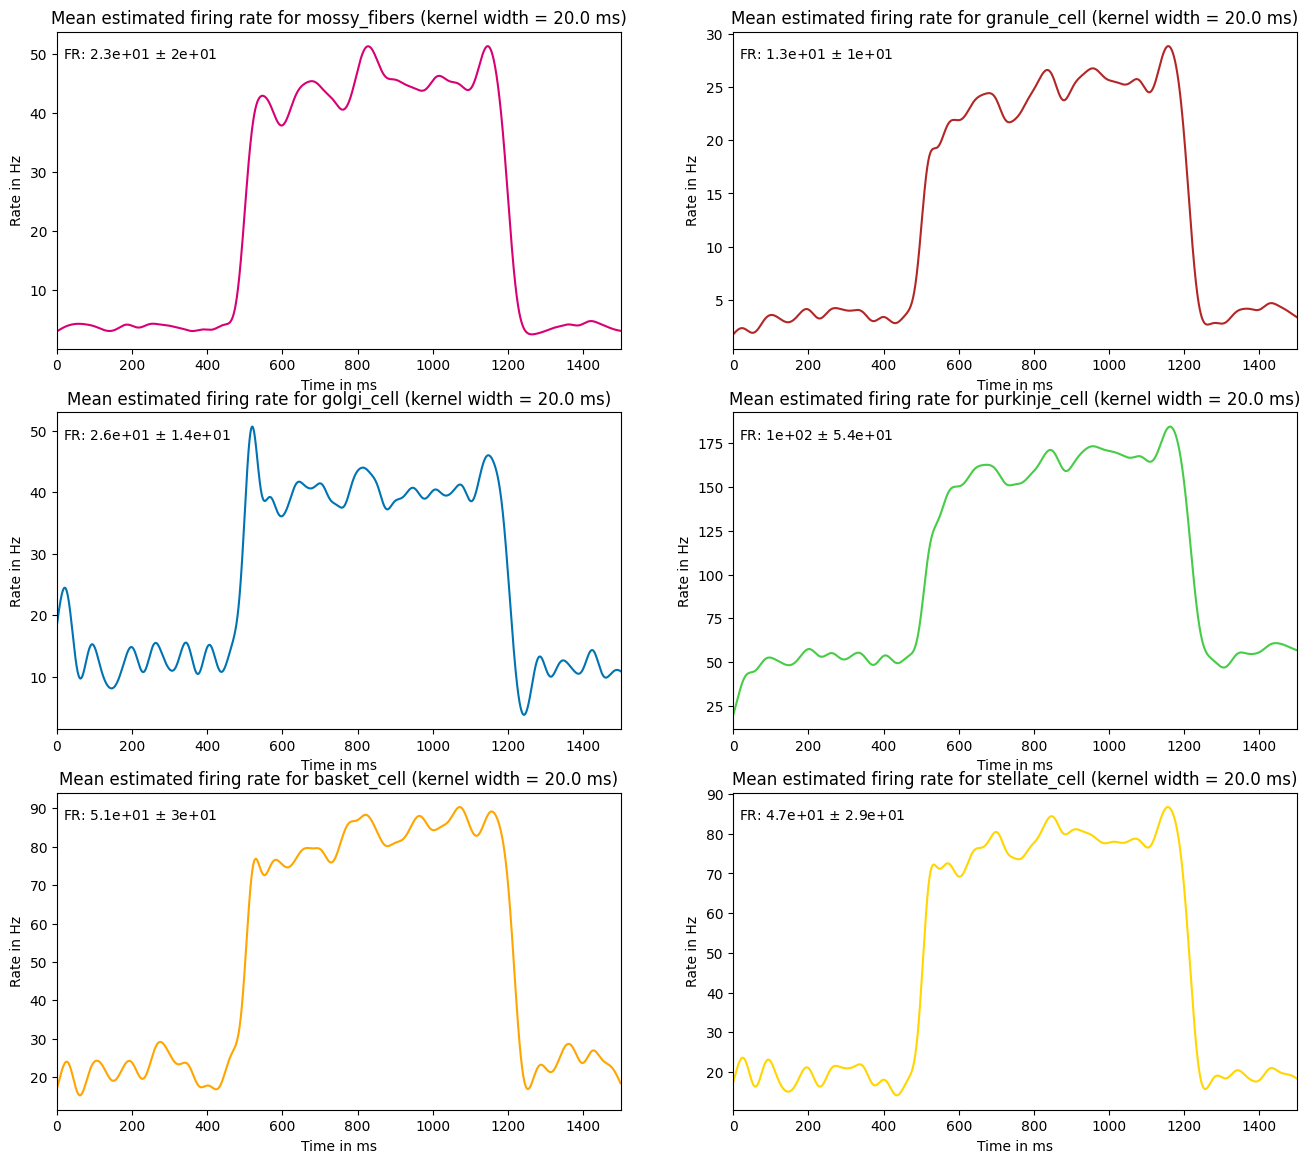

In [52]:
from cerebellar_models.analysis.spike_plots import FiringRatesPlot
from elephant.kernels import GaussianKernel
from quantities import ms

fr_plot = FiringRatesPlot(
    fig_size=(16, 14),
    spiking_results=report.spiking_results,
    kernel=GaussianKernel(sigma=20 * ms),
    dict_colors=report.plots["raster_psth"].labelled_dict_colors,
)
fr_plot.plot()

We will use these results in the **Day 4 tutorial** to compare the SNN dynamics with those of the corresponding mean field model.

# 2. Numerical transfer function Derivation


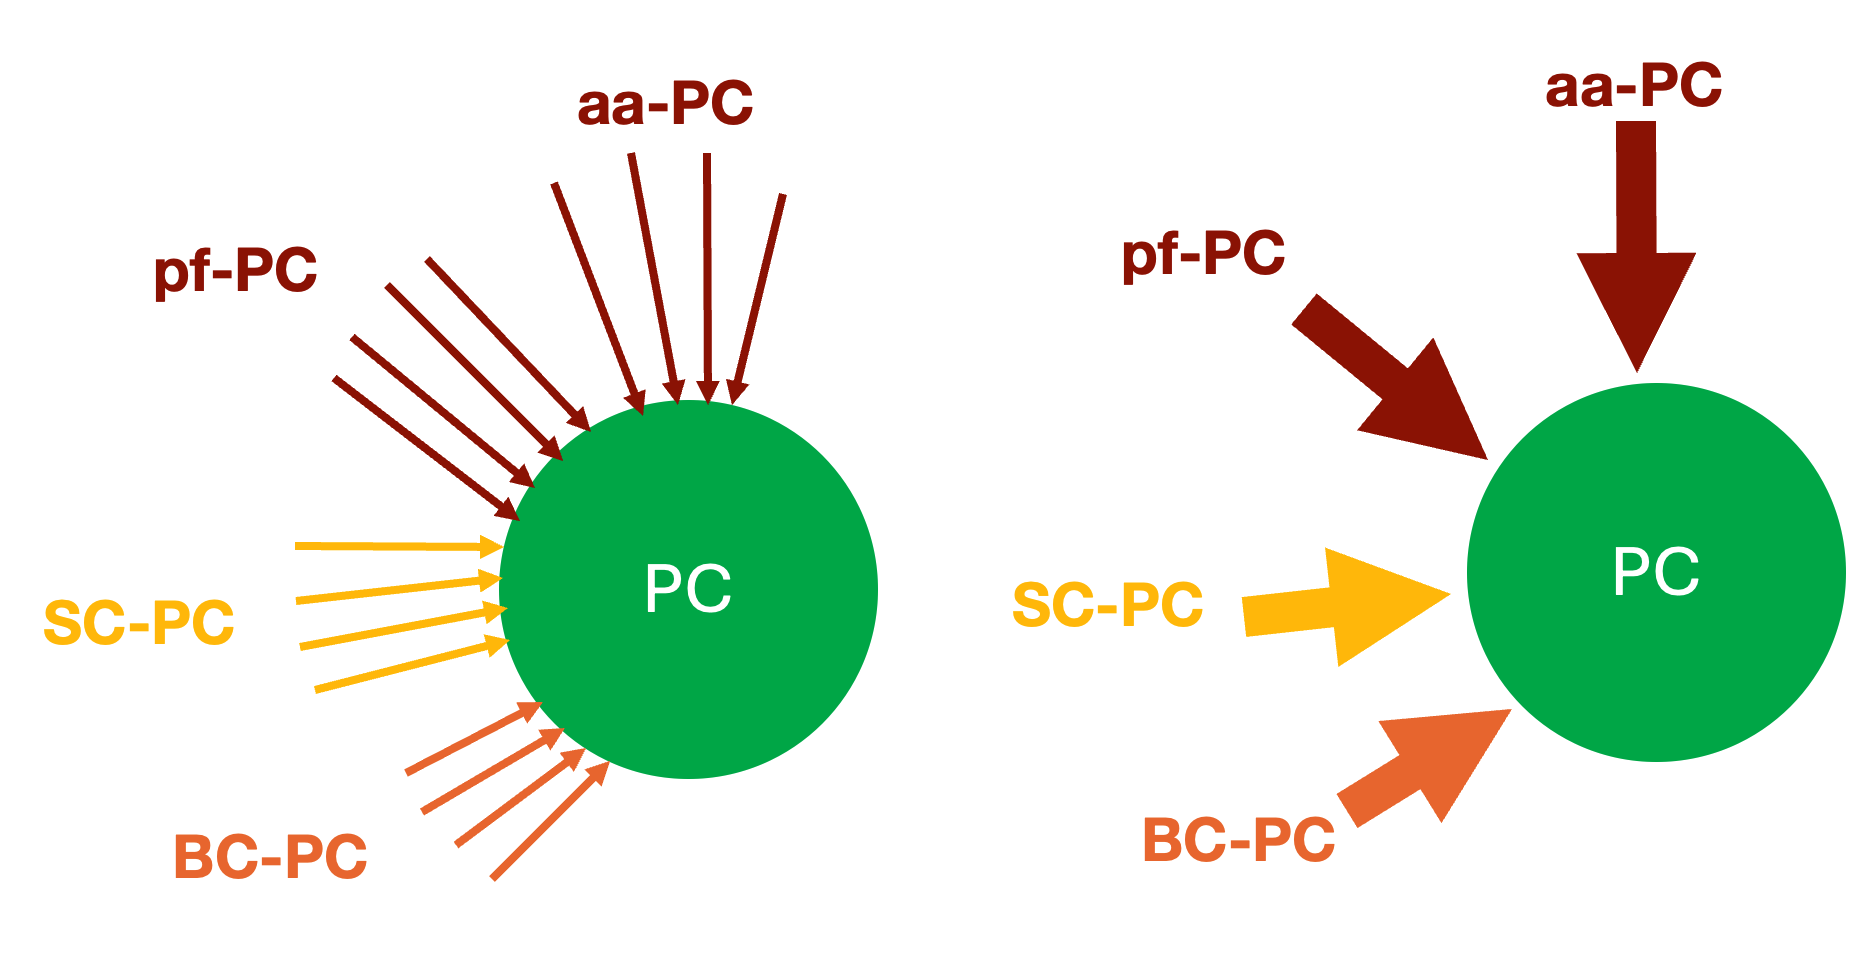

In [45]:
display(Image('figs/fig2.png'))

Considering a single postsynaptic neuron, if it receives $K$ incoming connections from population $\alpha$, with mean firing rate $m_\alpha$, the total input can be approximated as a Poisson process with rate

$$
r = K \, m_\alpha
$$

(El Boustani & Destexhe, 2009; [DOI: 10.1162/neco.2009.02-08-710](https://doi.org/10.1162/neco.2009.02-08-710)).

Here, $K$ is the mean convergence obtained from the circuit reconstruction. If each pre–post pair is connected by $n_{\mathrm{syn/pair}}$ synapses, the effective weight is

$$
w_{\mathrm{eff}} = w \, K \, n_{\mathrm{syn/pair}},
$$

where $w$ is the weight of a single synapse.

We focus on the numerical template for **Zebrin-positive Purkinje cells**. Purkinje cells are divided into parasagittal stripes by the expression of Zebrin II (aldolase C). Z+ and Z− cells differ in intrinsic firing (Z+ fire at lower rates; Zhou et al., 2014), connectivity and plasticity. A dedicated template is therefore needed for each subpopulation.


In [53]:
import numpy as np
import json
from utils.utils import load_yaml
import nest
from tqdm.notebook import tqdm

In [54]:
# Extract necessary information from BSB cerebellar circuit reconstruction
scaffold = from_storage('./utils/mouse_cerebellum.hdf5')

/usr/local/lib/python3.13/site-packages/bsb/config/_make.py:252: KernelWarning:Could not validate cell model 'parrot_neuron': NEST kernel subprocess exited with code 1 before accepting a connection.
/usr/local/lib/python3.13/site-packages/bsb/config/_make.py:252: KernelWarning:Could not validate cell model 'eglif_cond_alpha_multisyn': NEST kernel subprocess exited with code 1 before accepting a connection.
/usr/local/lib/python3.13/site-packages/bsb/config/_make.py:252: KernelWarning:Could not determine if delay is required for synapse 'static_synapse': NEST kernel subprocess exited with code 1 before accepting a connection.
/usr/local/lib/python3.13/site-packages/bsb/config/_make.py:252: KernelWarning:Could not validate synapse model 'static_synapse': NEST kernel subprocess exited with code 1 before accepting a connection.


In [55]:
report = StructureReport(scaffold)
conn_table = report.plots["connectivity_table"]
conn_table.update()

In [56]:
conn_of_interest = [
    'ascending_axon_to_purkinje',
    'parallel_fiber_to_purkinje',
    'stellate_to_purkinje',
    'basket_to_purkinje',
]

conn_table = report.plots["connectivity_table"]
conn_table.update()

# Per connectivity set: [n. synapses, synapses per pair, convergence, divergence]
stats = dict(zip((ps.tag for ps in scaffold.get_connectivity_sets()), conn_table._values))

# Convergence K: distinct presynaptic cells per postsynaptic cell (mean, std)
convergences = {
    tag: (np.mean(v[2]), np.std(v[2]))
    for tag, v in stats.items() if tag in conn_of_interest
}

# Mean number of synapses per connected pre-post pair
synapses_per_pair = {
    tag: np.mean(v[1])
    for tag, v in stats.items() if tag in conn_of_interest
}

for tag in conn_of_interest:
    K_mean, K_std = convergences[tag]
    print(f"{tag:30s}  K = {K_mean:8.2f} ± {K_std:6.2f}   n_syn/pair = {synapses_per_pair[tag]:.2f}")

ascending_axon_to_purkinje      K =    93.29 ±  26.93   n_syn/pair = 1.00
parallel_fiber_to_purkinje      K =  1525.07 ± 292.53   n_syn/pair = 1.00
stellate_to_purkinje            K =     4.67 ±   2.55   n_syn/pair = 9.54
basket_to_purkinje              K =    11.14 ±   4.83   n_syn/pair = 1.00


In [57]:
cell_name = "purkinje_cell"

In [58]:
# load circuit configuration to retreive NEST simulation parameters

circuit = load_yaml('./utils/circuit_Z+.yaml')

In [60]:
# load TF utils to set the transfer function protocol for a specific cell type (i.e. Purkinje Cell)

tf_dict_path = './utils/TF_dict.json'
with open(tf_dict_path) as f:
            tf_dict = json.load(f)

In [61]:
cell_data = tf_dict[cell_name]
cell_data

{'connections': {'ascending_axon_to_purkinje': {'label': 'GrC',
   'rate_range': [4, 40]},
  'parallel_fiber_to_purkinje': {'label': 'GrC', 'rate_range': [4, 40]},
  'basket_to_purkinje': {'label': 'MLI', 'rate_range': [4, 200]},
  'stellate_to_purkinje': {'label': 'MLI', 'rate_range': [4, 200]}}}

In [68]:
# NEST model parameters of the postsynaptic cell
cell_params = circuit["simulations"]["nest_simulation"]["cell_models"][cell_name]["constants"]
cell_params

{'C_m': 334,
 'E_L': -59,
 'V_m': -59,
 'V_min': -350,
 'V_reset': -69,
 'V_th': -43,
 't_ref': 0.5,
 'tau_m': 47,
 'A1': 1945.0,
 'A2': 4.96,
 'I_e': 158.59,
 'k_1': 0.29,
 'k_2': 0.035,
 'k_adap': 0.481,
 'lambda_0': 1000.0,
 'tau_V': 0.1,
 'tau_syn1': 1.1,
 'tau_syn2': 2.8,
 'tau_syn3': 0.4,
 'E_rev1': 0,
 'E_rev2': -80,
 'E_rev3': 0}

In [69]:
# Retreive NEST synaptic parameters for each connection in the simulation
conn_models = circuit["simulations"]["nest_simulation"]["connection_models"]
conn_models

{'mossy_fibers_to_glomerulus': {'synapses': [{'delay': 1.0,
    'model': 'static_synapse',
    'weight': 1.0}]},
 'glomerulus_to_granule': {'synapses': [{'delay': 1.0,
    'model': 'static_synapse',
    'receptor_type': 1,
    'weight': 0.23}]},
 'glomerulus_to_golgi': {'synapses': [{'delay': 1.0,
    'model': 'static_synapse',
    'receptor_type': 1,
    'weight': 0.24}]},
 'golgi_to_glomerulus': {'synapses': [{'delay': 2.0,
    'model': 'static_synapse',
    'receptor_type': 2,
    'weight': 0.24}]},
 'golgi_to_golgi': {'synapses': [{'delay': 4.0,
    'model': 'static_synapse',
    'receptor_type': 2,
    'weight': 0.007}]},
 'ascending_axon_to_golgi': {'synapses': [{'delay': 2.0,
    'model': 'static_synapse',
    'receptor_type': 3,
    'weight': 0.82}]},
 'parallel_fiber_to_golgi': {'synapses': [{'delay': 5.0,
    'model': 'static_synapse',
    'receptor_type': 3,
    'weight': 0.05}]},
 'ascending_axon_to_purkinje': {'synapses': [{'delay': 2.0,
    'model': 'static_synapse',
    

In [70]:
# Collect, for each afferent connection, the parameters needed for the presynaptic stimulation protocol
connections = {}
for conn_tag, conn_info in cell_data["connections"].items():
    s = conn_models[conn_tag]["synapses"][0]
    connections[conn_tag] = {
        "label": conn_info["label"],
        "convergence": convergences[conn_tag][0],
        "convergence_std": convergences[conn_tag][1],
        "synapses_per_pair": synapses_per_pair[conn_tag],
        "weight": s["weight"],
        "delay": s["delay"],
        "receptor_type": s.get("receptor_type", 1),
        "rate_range": conn_info["rate_range"],
    }
connections

{'ascending_axon_to_purkinje': {'label': 'GrC',
  'convergence': np.float64(93.28985507246377),
  'convergence_std': np.float64(26.933682080506156),
  'synapses_per_pair': np.float64(1.0),
  'weight': 0.41,
  'delay': 2.0,
  'receptor_type': 1,
  'rate_range': [4, 40]},
 'parallel_fiber_to_purkinje': {'label': 'GrC',
  'convergence': np.float64(1525.072463768116),
  'convergence_std': np.float64(292.5347158311191),
  'synapses_per_pair': np.float64(1.0),
  'weight': 0.14,
  'delay': 5.0,
  'receptor_type': 1,
  'rate_range': [4, 40]},
 'basket_to_purkinje': {'label': 'MLI',
  'convergence': np.float64(11.144927536231885),
  'convergence_std': np.float64(4.834283851520083),
  'synapses_per_pair': np.float64(1.0),
  'weight': 0.8,
  'delay': 4.0,
  'receptor_type': 2,
  'rate_range': [4, 200]},
 'stellate_to_purkinje': {'label': 'MLI',
  'convergence': np.float64(4.6716417910447765),
  'convergence_std': np.float64(2.547389999977399),
  'synapses_per_pair': np.float64(9.539936102236421),

In [71]:
def setup_grid(n_points):
  """
  Build the grid of presynaptic firing rates for the stimulation protocol.
  Connections sharing the same label (same presynaptic population, e.g. AA and PF from GrC) are grouped into one grid dimension and will receive the same rate.
  Returns:
      unique_labels: list of distinct presynaptic populations (one grid dimension each)
      label_to_idx:  label -> index of its grid dimension
      freq_axes:     for each label, n_points equally spaced rates within its rate_range
  Full grid size: n_points ** len(unique_labels).
  """
  label_to_range = {}
  for info in connections.values():
      if info["label"] not in label_to_range:
          label_to_range[info["label"]] = info["rate_range"]
  unique_labels = list(label_to_range.keys())
  label_to_idx = {lbl: i for i, lbl in enumerate(unique_labels)}
  freq_axes = [
      np.linspace(label_to_range[l][0], label_to_range[l][1], n_points)
      for l in unique_labels
  ]
  return unique_labels, label_to_idx, freq_axes

In [79]:
# set up numerical transfer function template
n_points = 15 # per axis
unique_labels, label_to_idx, freq_axes = setup_grid(n_points)
shape = tuple(len(ax) for ax in freq_axes)
n_points_total = int(np.prod(shape))

all_indices = list(np.ndindex(*shape))
tf_mean = np.zeros(shape)
tf_std = np.zeros(shape)

In [80]:
def rates_dict_(connections, idx, label_to_idx, freq_axes):
  """
  Map a grid point to the presynaptic rate of each connection.
  idx: tuple of indices, one per grid dimension (i.e. per presynaptic population).
  Returns {conn_tag: rate}; connections with the same label get the same rate.

   Example: unique_labels = ['GrC', 'SC', 'BC'],
             freq_axes = [[0, 10, 20], [0, 30, 60], [0, 20, 40]]
             idx = (2, 0, 1) -> GrC = 20 Hz (AA and PF), SC = 0 Hz, BC = 20 Hz
  """
  return {
      conn_tag: freq_axes[label_to_idx[info["label"]]][idx[label_to_idx[info["label"]]]]
      for conn_tag, info in connections.items()
  }


In [81]:
def connect_neuron(neuron, connections, rates_dict):
    """
    Wire one neuron to its Poisson generators according to presynaptic inputs. """
    for conn_tag, info in connections.items():
        rate = float(rates_dict[conn_tag])
        if rate <= 0:
            continue
        mean_conv = info["convergence"]
        n_syn = max(1, int(round(mean_conv)))
        n_syn_per_pair = max(1, int(round(info.get("synapses_per_pair", 1.0))))
        effective_weight = float(info["weight"]) * n_syn_per_pair
        pg = nest.Create("poisson_generator", 1, params={"rate": rate * n_syn})
        nest.Connect(
            pg,
            neuron,
            conn_spec={"rule": "all_to_all"},
            syn_spec={
                "synapse_model": "static_synapse",
                "weight": effective_weight,
                "delay": float(info["delay"]),
                "receptor_type": int(info["receptor_type"]),
            },
        )

In [82]:
def compute_tf_point(cell_params, rates_dict, duration = 10000, transient = 1000, n_reps = 1, seed = 1234):

  # Initialize NEST
  nest.ResetKernel()
  nest.set_verbosity("M_WARNING")
  nest.set(resolution=0.1, print_time=False, rng_seed=seed)
  nest.Install("cerebmodule")

  # Create neuron to simulate
  neurons = nest.Create("eglif_cond_alpha_multisyn", n_reps, params=cell_params)
  srs = nest.Create("spike_recorder", n_reps)

  for i in range(n_reps):
      rng = np.random.default_rng(seed + i)
      neuron = neurons[i : i + 1]
      nest.SetStatus(
          neuron, {"V_m": float(rng.uniform(cell_params["V_reset"], cell_params["V_th"] - 1.0))}
      )
      connect_neuron(neuron, connections, rates_dict)
      nest.Connect(neuron, srs[i : i + 1])

  nest.Simulate(duration)

  rep_rates = np.zeros(n_reps)
  for i in range(n_reps):
      spikes = srs[i].get("events")["times"]
      rep_rates[i] = np.sum(spikes > transient) / ((duration - transient) / 1000.0)

  return rep_rates.mean(), rep_rates.std()





In [83]:
for idx in tqdm(all_indices, desc=f"Computing transfer function for {cell_name}"):
    rates_dict = rates_dict_(connections, idx, label_to_idx, freq_axes)
    mean, std = compute_tf_point(cell_params, rates_dict)
    tf_mean[idx] = mean
    tf_std[idx] = std

Computing transfer function for purkinje_cell:   0%|          | 0/225 [00:00<?, ?it/s]

/usr/local/lib/python3.13/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
Provided for backward compatibility only. Set `nest.verbosity = nest.VerbosityLevel.XYZ` instead.
/usr/local/lib/python3.13/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
SetStatus() is deprecated and will be removed in a future version of NEST. Instead of SetStatus(nrns|conns, args), use nrns|conns.set(args).


In [84]:
# Save TF
os.makedirs('output_TF', exist_ok=True)
np.savez(f'output_TF/TF_{cell_name}.npz', tf_mean=tf_mean, tf_std=tf_std,
            tags = unique_labels, **{f"freq_axis_{t}": ax for t, ax in zip(unique_labels, freq_axes)},
        )

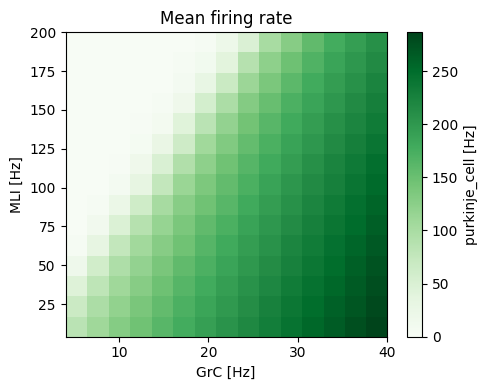

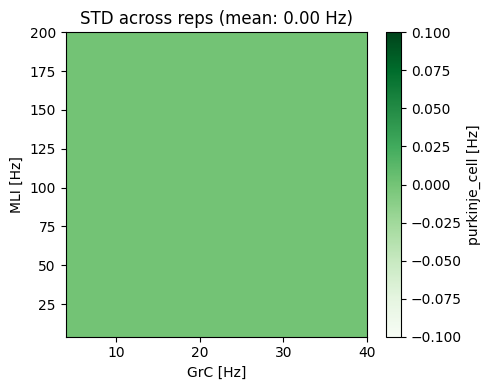

In [85]:
SAVE = True

extent = [
    freq_axes[0][0],
    freq_axes[0][-1],
    freq_axes[1][0],
    freq_axes[1][-1],
]


fig1, ax1 = plt.subplots(figsize=(5, 4))
im1 = ax1.imshow(tf_mean.T, origin="lower", aspect="auto", extent=extent, cmap='Greens')
ax1.set_title("Mean firing rate")
ax1.set_xlabel(f"{unique_labels[0]} [Hz]")
ax1.set_ylabel(f"{unique_labels[1]} [Hz]")
fig1.colorbar(im1, ax=ax1, label=f"{cell_name} [Hz]")
fig1.tight_layout()

mean_std = tf_std.mean()
fig2, ax2 = plt.subplots(figsize=(5, 4))
im2 = ax2.imshow(tf_std.T, origin="lower", aspect="auto", extent=extent, cmap='Greens')

ax2.set_title(f"STD across reps (mean: {mean_std:.2f} Hz)")
ax2.set_xlabel(f"{unique_labels[0]} [Hz]")
ax2.set_ylabel(f"{unique_labels[1]} [Hz]")
fig2.colorbar(im2, ax=ax2, label=f"{cell_name} [Hz]")
fig2.tight_layout()

if SAVE:
  os.makedirs('output_figs', exist_ok=True)
  fig1.savefig(f"./output_figs/TF_{cell_name}.png", dpi=150)
  fig2.savefig(f"./output_figs/TF_std_{cell_name}.png", dpi=150)

plt.show()



**Exercise:** Repeat the procedure for another cell type of the circuit.

**Challenge:** Golgi cells receive inputs from three distinct presynaptic populations, so their numerical template is three-dimensional.